In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import glob
import os

In [ ]:
folder_path = "/content/drive/MyDrive/IDS_Project"

In [ ]:
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

dataframes = []
for file in csv_files:
    print("Loading:", file)
    df = pd.read_csv(file)
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)
data.head()


Loading: /content/drive/MyDrive/IDS_Project/Wednesday-workingHours.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Tuesday-WorkingHours.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Monday-WorkingHours.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: /content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
#step 4.1:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"   # update to your actual dataset path
chunk_size = 400_000

cleaned_chunks = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    print(f"Processing chunk {i+1}...")

    # Replace infinities with NaN
    chunk = chunk.replace([np.inf, -np.inf], np.nan)

    # Drop NaN rows
    chunk = chunk.dropna()

    cleaned_chunks.append(chunk)
    print(f"Chunk {i+1} cleaned. Shape: {chunk.shape}")

# Combine all cleaned chunks into final df
df = pd.concat(cleaned_chunks, ignore_index=True)

print("✅ All chunks cleaned and combined!")
print("Final cleaned shape:", df.shape)


Processing chunk 1...
Chunk 1 cleaned. Shape: (225711, 79)
✅ All chunks cleaned and combined!
Final cleaned shape: (225711, 79)


In [ ]:
import os

clean_dir = "/content/drive/MyDrive/IDS_Project/Cleaned"
os.makedirs(clean_dir, exist_ok=True)

print("Cleaned folder is ready:", clean_dir)


Cleaned folder is ready: /content/drive/MyDrive/IDS_Project/Cleaned


In [ ]:
# Step 4.2: Drop useless or problematic columns

columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("Step 4.2 done!")
print("New shape:", df.shape)

# Save the cleaned dataset
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Friday_Afternoon_DDoS_clean.csv"
df.to_csv(save_path, index=False)

print("Cleaned file saved to:", save_path)



Step 4.2 done!
New shape: (225711, 79)
Cleaned file saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Friday_Afternoon_DDoS_clean.csv


In [ ]:
# Step 4.3: Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors='ignore')

print("Step 4.3 done!")
print("Columns converted where possible.")


Step 4.3 done!
Columns converted where possible.


/tmp/ipython-input-1907446761.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [ ]:
# Auto-detect the label column
label_col = None
for col in df.columns:
    if "label" in col.lower():
        label_col = col
        break

print("Detected label column:", label_col)



Detected label column:  Label


In [ ]:
#step 4.4:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df[label_col] = label_encoder.fit_transform(df[label_col])

X = df.drop(label_col, axis=1)
y = df[label_col]

print("Step 4.4 done!")
print("X shape:", X.shape)
print("y shape:", y.shape)


Step 4.4 done!
X shape: (225711, 78)
y shape: (225711,)


In [ ]:
#step 5.1: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split done!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)



Train/Test split done!
X_train: (180568, 78)
X_test: (45143, 78)


In [ ]:
#Step 5.2 — Standard Scaling (important for ML)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")


Scaling done!


In [ ]:
#Step 5.3 — Train my First ML Model: RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model trained!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model trained!
Accuracy: 0.9999113926854661

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19419
           1       1.00      1.00      1.00     25724

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



In [ ]:
# Step 6: Train & Compare Multiple Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

results = {}

print("Training and evaluating models...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

print("\n--- Classification Report of Best Model ---")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

preds = best_model.predict(X_test)
print(f"Best Model: {best_model_name}")
print(classification_report(y_test, preds))


Training and evaluating models...

Logistic Regression Accuracy: 0.9638
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 0.9999
KNN Accuracy: 0.9974
SVM Accuracy: 0.9367
Naive Bayes Accuracy: 0.8083
XGBoost Accuracy: 1.0000

--- Classification Report of Best Model ---
Best Model: XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19419
           1       1.00      1.00      1.00     25724

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



In [ ]:
#creating folder to save best model (Ran Once)
MODEL_DIR = "/content/drive/MyDrive/IDS_Project/Saved_Models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory ready:", MODEL_DIR)

Model directory ready: /content/drive/MyDrive/IDS_Project/Saved_Models


In [ ]:
#step 7.1: Save the best model for file 1 (Ran Once)
import joblib

# Save the XGBoost model
model_path = "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File1_BestModel.pkl"
joblib.dump(best_model, model_path)

print("File 1 model saved at:", model_path)



File 1 model saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File1_BestModel.pkl


In [ ]:
#Step 7.2 – Load the Model Anytime (for my defense)

import joblib

model = joblib.load(
    "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File1_BestModel.pkl"
)

print("File 1 model loaded successfully!")


File 1 model loaded successfully!


In [ ]:
#Step 7.3 – Make a Test Prediction (I will show this in my defense)
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)


Prediction: [0]


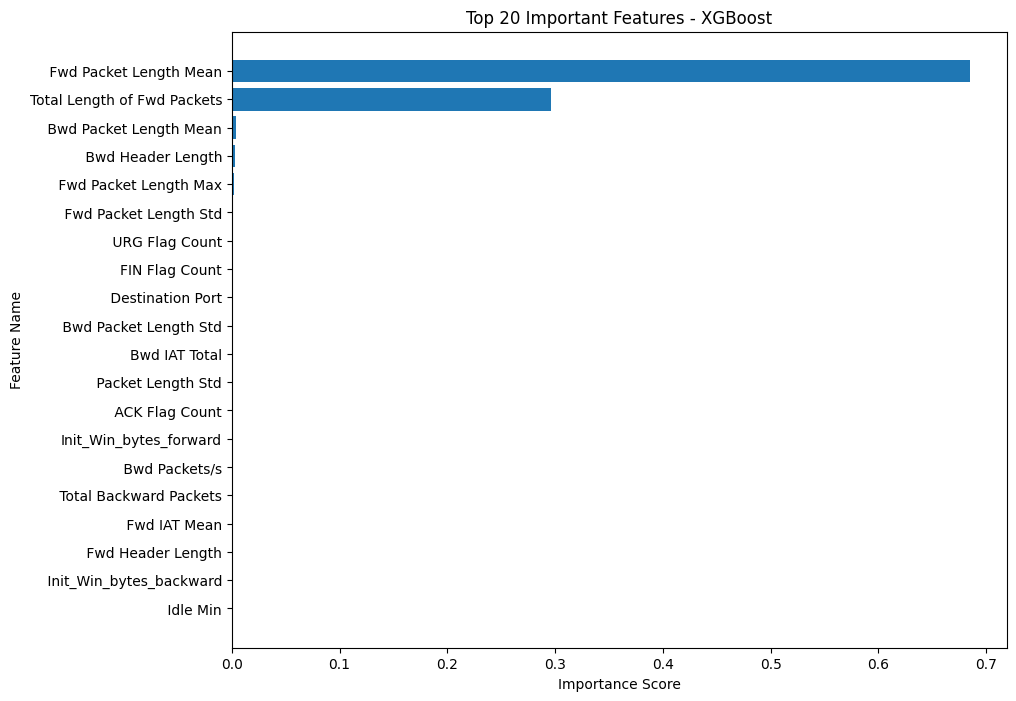

In [ ]:
#Step 8:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance from the best model (XGBoost)
importance = best_model.feature_importances_

# Get feature names
feature_names = X.columns

# Sort features by importance
indices = np.argsort(importance)[::-1]

# Top 20 features
top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(feature_names[indices][:top_n], importance[indices][:top_n])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.show()


In [ ]:
#Step 4.1.2 – Load File 2
file_path = "/content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
df2 = pd.read_csv(file_path)

print("Loaded File 2!")
print(df2.shape)
df2.head()


Loaded File 2!
(286467, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Step 4.2.2 – Clean Data (Remove infinities, NaNs)
import numpy as np

df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna()

print("After cleaning:", df2.shape)

#Drop useless columns
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

df2 = df2.drop(columns=[col for col in columns_to_drop if col in df2.columns])

print("Columns dropped. New shape:", df2.shape)

#Save cleaned File 2
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Friday_Afternoon_PortScan_clean.csv"
df2.to_csv(save_path, index=False)

print("Cleaned File 2 saved to:", save_path)


After cleaning: (286096, 79)
Columns dropped. New shape: (286096, 79)
Cleaned File 2 saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Friday_Afternoon_PortScan_clean.csv


In [ ]:
#Step 4.3.2 – Detect Label Column
label_col = None
for col in df2.columns:
    if col.lower() == "label":
        label_col = col
        break

print("Detected label column:", label_col)

Detected label column: None


In [ ]:
#Identify the actual label column for file 2
print(df2.columns.tolist())





[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [ ]:
#Step 4.4.2 – Encode Labels
from sklearn.preprocessing import LabelEncoder

label_col2 = " Label"   # <-- notice the space!
label_encoder2 = LabelEncoder()

df2[label_col2] = label_encoder2.fit_transform(df2[label_col2])

X2 = df2.drop(label_col2, axis=1)
y2 = df2[label_col2]

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)
print("Step 4 for File 2 done!")


X2 shape: (286096, 78)
y2 shape: (286096,)
Step 4 for File 2 done!


In [ ]:
#5.1.2 FIX: Recreate X2 and y2 AFTER cleaning

label_col2 = " Label"

X2 = df2.drop(label_col2, axis=1)
y2 = df2[label_col2]

print("X2 shape (recreated):", X2.shape)
print("y2 shape (recreated):", y2.shape)


X2 shape (recreated): (286096, 78)
y2 shape (recreated): (286096,)


In [ ]:
#5.2.2 — Train/Test Split
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Train shape:", X2_train.shape)
print("Test shape:", X2_test.shape)


Train shape: (228876, 78)
Test shape: (57220, 78)


In [ ]:
#5.3.2 — Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("Scaling done for File 2!")


Scaling done for File 2!


In [ ]:
# Step 6 — Train & Evaluate Models for File 2 (Combined)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Training and evaluating File 2 models...\n")

models2 = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

results2 = {}
best_model2 = None
best_acc2 = 0

for name, model in models2.items():
    model.fit(X2_train_scaled, y2_train)
    preds = model.predict(X2_test_scaled)
    acc = accuracy_score(y2_test, preds)
    results2[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

    if acc > best_acc2:
        best_acc2 = acc
        best_model2 = model

print("\n--- Best Model for File 2 ---")
print("Best Model:", best_model2.__class__.__name__)
print("Accuracy:", best_acc2)

print("\n--- Classification Report ---")
preds_best = best_model2.predict(X2_test_scaled)
print(classification_report(y2_test, preds_best))


Training and evaluating File 2 models...

Logistic Regression Accuracy: 0.9991
Decision Tree Accuracy: 0.9999
Random Forest Accuracy: 0.9999
KNN Accuracy: 0.9999
SVM Accuracy: 0.9993
Naive Bayes Accuracy: 0.9942
XGBoost Accuracy: 0.9999

--- Best Model for File 2 ---
Best Model: XGBClassifier
Accuracy: 0.9999475707794477

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25459
           1       1.00      1.00      1.00     31761

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220



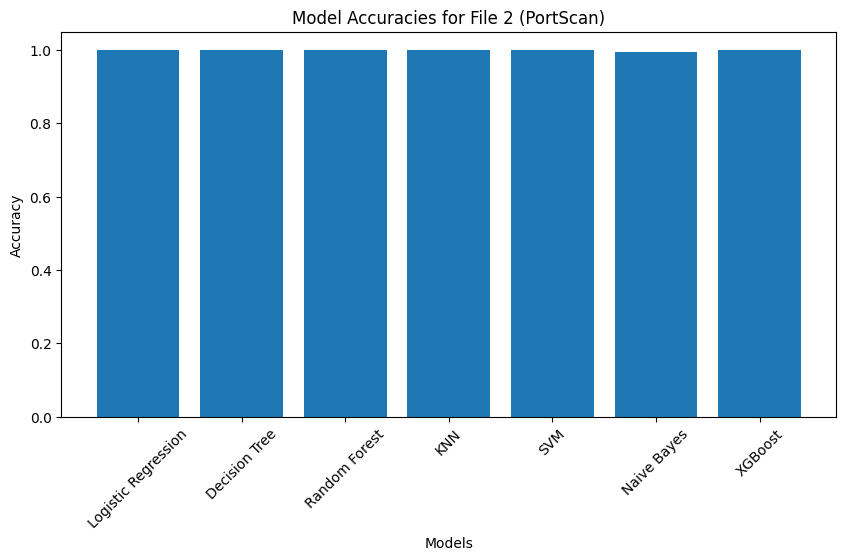

In [ ]:
import matplotlib.pyplot as plt

# Step 6.1.2 – Compare File 2 Models

model_names2 = list(results2.keys())
accuracies2 = list(results2.values())

plt.figure(figsize=(10, 5))
plt.bar(model_names2, accuracies2)
plt.xticks(rotation=45)
plt.title("Model Accuracies for File 2 (PortScan)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
# Step 7.1 — Save Best Model for File 2 (ran once)

import joblib

save_path = "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File2_BestModel.pkl"
joblib.dump(best_model2, save_path)

print("File 2 best model saved successfully!")
print("Saved at:", save_path)




File 2 best model saved successfully!
Saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File2_BestModel.pkl


In [ ]:
# Step 7.2 — Load Saved Model for File 2

import joblib

model_file2 = joblib.load(
    "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File2_BestModel.pkl"
)

print("File 2 model loaded successfully!")

File 2 model loaded successfully!


In [ ]:
# Step 7.3 — Prediction using saved model (File 2)

sample = X2_test_scaled[0:1]   # already scaled
prediction = model_file2.predict(sample)

print("Prediction:", prediction)


Prediction: [1]


In [ ]:
# Step 1 — Load File 3
import pandas as pd

file3_path = "/content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Morning.pcap_ISCX.csv"
df3 = pd.read_csv(file3_path)

print("Loaded File 3:", file3_path)
print("Shape:", df3.shape)
df3.head()


Loaded File 3: /content/drive/MyDrive/IDS_Project/Friday-WorkingHours-Morning.pcap_ISCX.csv
Shape: (191033, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [ ]:
# Step 2 — Clean infinities and NaNs
import numpy as np

df3 = df3.replace([np.inf, -np.inf], np.nan)
df3 = df3.dropna()

print("After cleaning:", df3.shape)

# Drop useless columns
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

df3 = df3.drop(columns=[col for col in columns_to_drop if col in df3.columns])

print("After dropping ID/IP/Timestamp columns:", df3.shape)

#Save Cleaned File 3
clean_path3 = "/content/drive/MyDrive/IDS_Project/Cleaned/Friday_Morning_clean.csv"
df3.to_csv(clean_path3, index=False)

print("File 3 cleaned and saved successfully!")
print("Saved to:", clean_path3)



After cleaning: (190911, 79)
After dropping ID/IP/Timestamp columns: (190911, 79)
File 3 cleaned and saved successfully!
Saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Friday_Morning_clean.csv


In [ ]:
# Step 3 — Detect label column robustly
label_col3 = None
for col in df3.columns:
    if col.strip().lower() == "label":
        label_col3 = col
        break

print("Detected label column for file3:", label_col3)
print(df3.columns.tolist())


Detected label column for file3:  Label
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Fla

In [ ]:
# Step 4 — Encode label and create X,y
from sklearn.preprocessing import LabelEncoder

if label_col3 is None:
    raise ValueError("No label column found — check df3.columns output from Step 3.")

le3 = LabelEncoder()
df3[label_col3] = le3.fit_transform(df3[label_col3])

X3 = df3.drop(columns=[label_col3])
y3 = df3[label_col3]

print("X3 shape:", X3.shape)
print("y3 shape:", y3.shape)


X3 shape: (190911, 78)
y3 shape: (190911,)


In [ ]:
#Step 5.1.3
#Cell 1 — Imports (Always run)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import joblib


In [ ]:
#Step 5.2.3 Cell 2 — Train-test split for File 3 (Always run)
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)


In [ ]:
#Step 5.3.3 Cell 3 — Define models for File 3
models3 = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        eval_metric="logloss",
        n_jobs=-1
    )
}

accuracies3 = {}
best_model_name3 = None
best_accuracy3 = 0
best_model3 = None


In [ ]:
#Step 5.4.3 Cell 4 — Train all models (Heavy cell — run only once)
print("Training and evaluating File 3 models...\n")

for name, model in models3.items():
    model.fit(X_train3, y_train3)
    preds = model.predict(X_test3)
    acc = accuracy_score(y_test3, preds)
    accuracies3[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

    if acc > best_accuracy3:
        best_accuracy3 = acc
        best_model_name3 = name
        best_model3 = model

print("\n--- Best Model for File 3 ---")
print("Best Model:", best_model_name3)
print("Accuracy:", best_accuracy3)


Training and evaluating File 3 models...

Logistic Regression Accuracy: 0.9922
Decision Tree Accuracy: 0.9998
Random Forest Accuracy: 0.9994
KNN Accuracy: 0.9958
SVM Accuracy: 0.9891
Naive Bayes Accuracy: 0.3778
XGBoost Accuracy: 0.9998

--- Best Model for File 3 ---
Best Model: Decision Tree
Accuracy: 0.9997642930099783


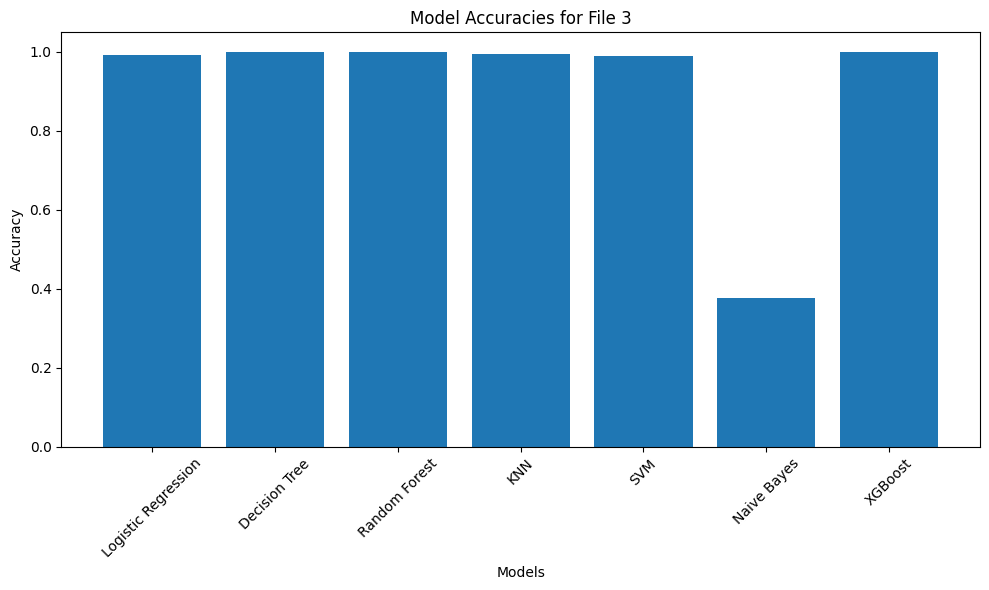

In [ ]:
# Cell 8 — Bar Chart of Model Accuracies for File 3

import matplotlib.pyplot as plt

# Extract names and accuracies
model_names = list(accuracies3.keys())
model_scores = list(accuracies3.values())

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracies for File 3")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Step 6.1 — Save Best Model for File 3 (ran once)

import joblib

save_path = "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File3_BestModel.pkl"
joblib.dump(best_model3, save_path)

print("File 3 best model saved successfully!")
print("Best Model:", best_model_name3)
print("Accuracy:", best_accuracy3)
print("Saved at:", save_path)


File 3 best model saved successfully!
Best Model: Decision Tree
Accuracy: 0.9997642930099783
Saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File3_BestModel.pkl


In [ ]:
# Step 6.2 — Load Saved Model for File 3

import joblib

model_file3 = joblib.load(
    "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File3_BestModel.pkl"
)

print("File 3 model loaded successfully!")

File 3 model loaded successfully!


In [ ]:
# Step 6.3 — Prediction using saved model (File 3)

sample = X_test3[0:1]
prediction = model_file3.predict(sample)

print("Prediction:", prediction)
print("Actual label:", y_test3.iloc[0])


Prediction: [0]
Actual label: 0


In [ ]:
# Step 1 — Load File 4 (Run Every Time)

import pandas as pd

file4_path = "/content/drive/MyDrive/IDS_Project/Monday-WorkingHours.pcap_ISCX.csv"

df4 = pd.read_csv(file4_path, low_memory=False)
print("File 4 loaded successfully!")
df4.head()


File 4 loaded successfully!


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Step 2 — Clean File 4 (Run Once Only unless the file is changed)

# Convert infinite values to NaN
df4.replace([float('inf'), -float('inf')], pd.NA, inplace=True)

# Drop rows with NaN
df4.dropna(inplace=True)

print("After cleaning:", df4.shape)

# Save the cleaned dataset
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Monday_WorkingHours_clean.csv"
df4.to_csv(save_path, index=False)

print(" Cleaned file saved to:", save_path)


After cleaning: (529481, 79)
 Cleaned file saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Monday_WorkingHours_clean.csv


In [ ]:
# Step 3 — Detect Label Column (Run Once)

label_col4 = None
for col in df4.columns:
    if col.strip().lower() == "label":
        label_col4 = col
        break

print("Detected label column for File 4:", label_col4)
print(df4.columns.tolist())


Detected label column for File 4:  Label
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Fl

In [ ]:
# Step 4 — Split Feature Matrix X4 and Target y4 (Run Every Time)

X4 = df4.drop(columns=[label_col4])
y4 = df4[label_col4]

print("X4 shape:", X4.shape)
print("y4 shape:", y4.shape)


X4 shape: (529481, 78)
y4 shape: (529481,)


In [ ]:
#Step 5 CELL A — Inspect the labels for File 4 (Run Every Time after loading/cleaning)
print("Unique labels:", y4.unique())
print("\nLabel counts:\n", y4.value_counts())


Unique labels: ['BENIGN']

Label counts:
  Label
BENIGN    529481
Name: count, dtype: int64


In [ ]:
# Step 6 (File 4) — Create & Save Dummy Baseline Model (Run ONCE)
from sklearn.dummy import DummyClassifier
import joblib

dummy4 = DummyClassifier(strategy="most_frequent")
dummy4.fit(X4, y4)

joblib.dump(dummy4, "IDS_File4_DummyModel.pkl")
print("Dummy model saved successfully!")


Dummy model saved successfully!


In [ ]:
# Step 7 (File 4) — Load Dummy Model
import joblib

model4 = joblib.load("IDS_File4_DummyModel.pkl")
print("Dummy model loaded successfully!")


Dummy model loaded successfully!


In [ ]:
# Step 8 (File 4) — Test Prediction
sample4 = X4.iloc[0:1]
prediction4 = model4.predict(sample4)

print("Prediction:", prediction4)


Prediction: ['BENIGN']


In [ ]:
# Step 1 — Load CSV file 5(Run Every Time)

import pandas as pd

file5_path = "/content/drive/MyDrive/IDS_Project/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"

df5 = pd.read_csv(file5_path)
print("File 5 loaded!")
df5.head()


File 5 loaded!


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [ ]:
# Step 5 — Clean File 5 (Run Once Only Unless File Changes)

# Remove rows with NaN
df5 = df5.dropna()

# Replace infinities with 0
df5 = df5.replace([float("inf"), -float("inf")], 0)

print("After cleaning:", df5.shape)

# Save cleaned file
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Thursday_Afternoon_Infiltration_clean.csv"
df5.to_csv(save_path, index=False)

print("Cleaned file saved to:", save_path)


After cleaning: (288584, 79)
Cleaned file saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Thursday_Afternoon_Infiltration_clean.csv


In [ ]:
# Step 3 — Detect Label Column (Run Once)
label_col5 = None
for col in df5.columns:
    if col.strip().lower() == "label":
        label_col5 = col
        break

print("Detected label column:", label_col5)


Detected label column:  Label


In [ ]:
# Step 4 — Split Feature Matrix and Target (Run Every Time)

X5 = df5.drop(columns=[label_col5])
y5 = df5[label_col5]

print("X5:", X5.shape)
print("y5:", y5.shape)


X5: (288584, 78)
y5: (288584,)


In [ ]:
# Step 5 — Check Class Distribution (Run Every Time)

print("Unique labels:", y5.unique())
print("\nLabel counts:")
print(y5.value_counts())


Unique labels: ['BENIGN' 'Infiltration']

Label counts:
 Label
BENIGN          288548
Infiltration        36
Name: count, dtype: int64


In [ ]:
#Step 6 Encode Labels into 0/1 (Run Once)
from sklearn.preprocessing import LabelEncoder

le5 = LabelEncoder()
y5_encoded = le5.fit_transform(y5)

print("Encoded classes:", le5.classes_)


Encoded classes: ['BENIGN' 'Infiltration']


In [ ]:
#Step 7 — Train Models (Run Once)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Training models for File 5...\n")

X5_train, X5_test, y5_train_enc, y5_test_enc = train_test_split(
    X5, y5_encoded, test_size=0.2, random_state=42, stratify=y5_encoded
)

models5 = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss")
}

for name, model in models5.items():
    model.fit(X5_train, y5_train_enc)
    preds = model.predict(X5_test)
    acc = accuracy_score(y5_test_enc, preds)
    print(f"{name} Accuracy: {acc:.4f}")


Training models for File 5...

Logistic Regression Accuracy: 0.9998
Decision Tree Accuracy: 0.9999
Random Forest Accuracy: 1.0000
SVM Accuracy: 0.9999
XGBoost Accuracy: 1.0000


In [ ]:
# Step 7.1 — Save Best Model for File 5 (Run once)

import joblib
import os

save_dir = "/content/drive/MyDrive/IDS_Project/Saved_Models"
os.makedirs(save_dir, exist_ok=True)

best_model5 = None
best_acc5 = 0
best_model_name5 = ""

for name, model in models5.items():
    preds = model.predict(X5_test)
    acc = accuracy_score(y5_test_enc, preds)

    if acc > best_acc5:
        best_acc5 = acc
        best_model5 = model
        best_model_name5 = name

save_path = f"{save_dir}/IDS_File5_{best_model_name5.replace(' ', '_')}.pkl"
joblib.dump(best_model5, save_path)

print("✅ Best model saved for File 5")
print("Model:", best_model_name5)
print("Accuracy:", best_acc5)
print("Saved at:", save_path)


✅ Best model saved for File 5
Model: XGBoost
Accuracy: 0.9999826740821595
Saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File5_XGBoost.pkl


In [ ]:
# Step 7.2 — Load Saved Model for File 5 (Run anytime)

import joblib

save_path = "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File5_XGBoost.pkl"
model5 = joblib.load(save_path)

print("✅ File 5 model loaded successfully!")
print("Loaded model:", model5.__class__.__name__)


✅ File 5 model loaded successfully!
Loaded model: XGBClassifier


In [ ]:
# Step 7.3 — Make a Sample Prediction (Defense Demo)

sample = X5_test.iloc[0:1]
prediction = model5.predict(sample)

print("Predicted encoded label:", prediction[0])


Predicted encoded label: 0


In [ ]:
# Step 1 — Load File 6 Dataset (Run Every Time)

import pandas as pd

file6_path = "/content/drive/MyDrive/IDS_Project/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"

df6 = pd.read_csv(file6_path)

print("File 6 loaded successfully!")
df6.head()


File 6 loaded successfully!


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [ ]:
# Step 2 — Clean File 6 (Run Once Only Unless File Changes)

# Replace missing values with 0
df6 = df6.fillna(0)

print("After cleaning:", df6.shape)

# Save cleaned file
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Thursday_Morning_WebAttacks_clean.csv"
df6.to_csv(save_path, index=False)

print(" Cleaned file saved to:", save_path)


After cleaning: (170366, 79)
 Cleaned file saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Thursday_Morning_WebAttacks_clean.csv


In [ ]:
# Step 3 — Detect Label Column (Run Once)

label_col6 = None
for col in df6.columns:
    if col.lower().strip() == "label":
        label_col6 = col
        break

print("Detected label column:", label_col6)


Detected label column:  Label


In [ ]:
df6[label_col6].value_counts()


,count
Label,
BENIGN,168186
Web Attack � Brute Force,1507
Web Attack � XSS,652
Web Attack � Sql Injection,21


In [ ]:
# Step 4 — Define Feature Matrix and Target (Run Every Time)

X6 = df6.drop(columns=[label_col6])
y6 = df6[label_col6]

print("X6 shape:", X6.shape)
print("y6 shape:", y6.shape)


X6 shape: (170366, 78)
y6 shape: (170366,)


In [ ]:
# Step 5 — Encode Labels (Run Once)

from sklearn.preprocessing import LabelEncoder

le6 = LabelEncoder()
y6_encoded = le6.fit_transform(y6)

print("Classes mapped as:", dict(zip(le6.classes_, le6.transform(le6.classes_))))


Classes mapped as: {'BENIGN': np.int64(0), 'Web Attack � Brute Force': np.int64(1), 'Web Attack � Sql Injection': np.int64(2), 'Web Attack � XSS': np.int64(3)}


In [ ]:
# Step 6 — Train-Test Split (Run Every Time)

from sklearn.model_selection import train_test_split

X6_train, X6_test, y6_train, y6_test = train_test_split(
    X6, y6_encoded, test_size=0.2, random_state=42, stratify=y6_encoded
)

print("Train/test ready for File 6!")


Train/test ready for File 6!


In [ ]:
import numpy as np

# Clean training set
X6_train = X6_train.replace([np.inf, -np.inf], np.nan)
X6_train = X6_train.fillna(X6_train.median())

# Clean test set
X6_test = X6_test.replace([np.inf, -np.inf], np.nan)
X6_test = X6_test.fillna(X6_test.median())


In [ ]:
# Step 7 — Feature Scaling (Run Once)
from sklearn.preprocessing import StandardScaler

scaler6 = StandardScaler()
X6_train_scaled = scaler6.fit_transform(X6_train)
X6_test_scaled = scaler6.transform(X6_test)

print("Scaling done for File 6!")


Scaling done for File 6!


In [ ]:
# Step 8 — Train Models with Class Weights (Run Once — Takes Time)

from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

print("Training File 6 models...\n")

class_weights = "balanced"

models6 = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight=class_weights),
    "Decision Tree": DecisionTreeClassifier(class_weight=class_weights),
    "Random Forest": RandomForestClassifier(class_weight=class_weights),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=250,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="mlogloss",
        scale_pos_weight=10  # Boost minority classes
    )
}

accuracies6 = {}
best_model6 = None
best_acc6 = -1
best_name6 = None

for name, model in models6.items():
    model.fit(X6_train_scaled, y6_train)
    preds = model.predict(X6_test_scaled)
    acc = accuracy_score(y6_test, preds)
    accuracies6[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

    if acc > best_acc6:
        best_acc6 = acc
        best_name6 = name
        best_model6 = model

print("\nBest Model:", best_name6)
print("Accuracy:", best_acc6)
print("\nClassification Report:\n")
print(classification_report(y6_test, best_model6.predict(X6_test_scaled)))


Training File 6 models...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.9634
Decision Tree Accuracy: 0.9953
Random Forest Accuracy: 0.9957


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:08:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9964

Best Model: XGBoost
Accuracy: 0.9963902095439338

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33638
           1       0.77      0.87      0.82       302
           2       1.00      0.75      0.86         4
           3       0.56      0.35      0.43       130

    accuracy                           1.00     34074
   macro avg       0.83      0.74      0.78     34074
weighted avg       1.00      1.00      1.00     34074



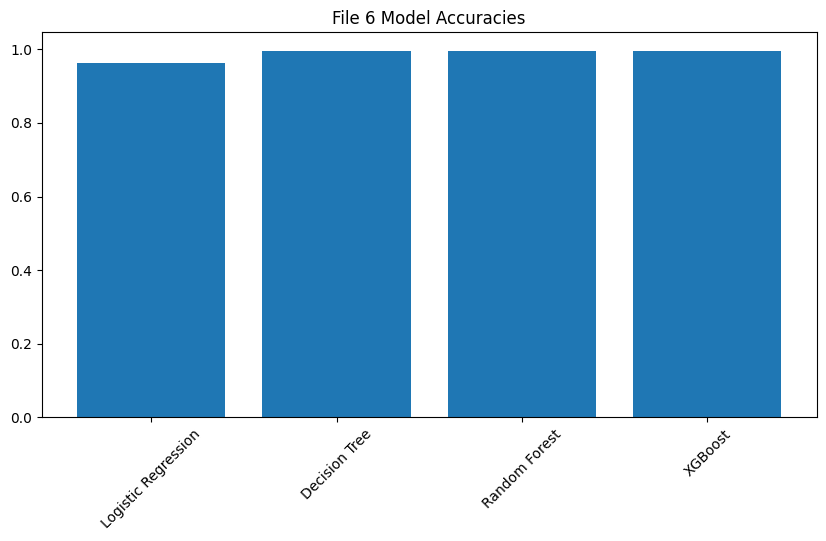

In [ ]:
# Step 9 — Bar Chart (Run Once)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(accuracies6.keys(), accuracies6.values())
plt.xticks(rotation=45)
plt.title("File 6 Model Accuracies")
plt.show()


In [ ]:
# Step 8.1 — Save Best Model for File 6 (Run once)

import joblib
import os

save_dir = "/content/drive/MyDrive/IDS_Project/Saved_Models"
os.makedirs(save_dir, exist_ok=True)

save_path6 = f"{save_dir}/IDS_File6_{best_name6.replace(' ', '_')}.pkl"

joblib.dump(best_model6, save_path6)

print("✅ Best model saved for File 6")
print("Model:", best_name6)
print("Accuracy:", best_acc6)
print("Saved at:", save_path6)


✅ Best model saved for File 6
Model: XGBoost
Accuracy: 0.9963902095439338
Saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File6_XGBoost.pkl


In [ ]:
# Step 8.2 — Load Saved Model for File 6 (Run anytime)

import joblib

save_path6 = "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File6_XGBoost.pkl"
model6 = joblib.load(save_path6)

print("✅ File 6 model loaded successfully!")
print("Loaded model:", model6.__class__.__name__)


✅ File 6 model loaded successfully!
Loaded model: XGBClassifier


In [ ]:
# Step 8.3 — Make a Sample Prediction (Defense Demo)

sample = X6_test_scaled[0:1]
prediction = model6.predict(sample)

print("Predicted label:", prediction[0])

Predicted label: 0


In [ ]:
#Step 1 — Load File 7
import pandas as pd

file7_path = "/content/drive/MyDrive/IDS_Project/Tuesday-WorkingHours.pcap_ISCX.csv"

df7 = pd.read_csv(file7_path)

df7.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
#Clean File 7 (Run Once Only Unless File Changes)

import numpy as np

# Replace infinities with NaN
df7 = df7.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN
df7 = df7.dropna()

print("After cleaning:", df7.shape)

# Save cleaned dataset
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Tuesday_WorkingHours_clean.csv"
df7.to_csv(save_path, index=False)

print(" Cleaned file saved to:", save_path)


After cleaning: (445645, 79)
 Cleaned file saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Tuesday_WorkingHours_clean.csv


In [ ]:
#Step 2 (Fix) — Detect the Actual Label Column
label_col7 = None

for col in df7.columns:
    if "label" in col.lower():
        label_col7 = col
        break

print("Detected label column:", label_col7)


Detected label column:  Label


In [ ]:
#Step 3 — Check Label Values
print(df7[label_col7].unique())
print("\nLabel counts:\n")
print(df7[label_col7].value_counts())


['BENIGN' 'FTP-Patator' 'SSH-Patator']

Label counts:

 Label
BENIGN         431813
FTP-Patator      7935
SSH-Patator      5897
Name: count, dtype: int64


In [ ]:
#Step 4 — Encode Labels (Run Once)
from sklearn.preprocessing import LabelEncoder

le7 = LabelEncoder()
df7["LabelEncoded"] = le7.fit_transform(df7[label_col7])

print("Encoded labels:", le7.classes_)


Encoded labels: ['BENIGN' 'FTP-Patator' 'SSH-Patator']


In [ ]:
#Define X7 and y7 (run every time)
X7 = df7.drop(columns=[label_col7])
y7 = df7[label_col7]


In [ ]:
import numpy as np

# Clean full X7 BEFORE splitting
X7 = X7.replace([np.inf, -np.inf], np.nan)
X7 = X7.fillna(X7.median(numeric_only=True))


In [ ]:
#Step 5 (train-test split) Run Once
from sklearn.model_selection import train_test_split

X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.2, random_state=42, stratify=y7
)


In [ ]:
#Step 6 — Scaling (Run Once)
from sklearn.preprocessing import StandardScaler

scaler7 = StandardScaler()
X7_train_scaled = scaler7.fit_transform(X7_train)
X7_test_scaled = scaler7.transform(X7_test)

print("Scaling successful!")


Scaling successful!


In [ ]:
#STEP 6 — Train models (Run once)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models7 = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=120),
    "KNN": KNeighborsClassifier()
}

accuracies7 = {}

for name, model in models7.items():
    model.fit(X7_train_scaled, y7_train)
    acc = model.score(X7_test_scaled, y7_test)
    accuracies7[name] = acc


In [ ]:
#STEP 7 — Print accuracies (Run every time)
for name, acc in accuracies7.items():
    print(f"{name}: {acc:.4f}")


Logistic Regression: 0.9927
Decision Tree: 1.0000
Random Forest: 1.0000
KNN: 0.9997


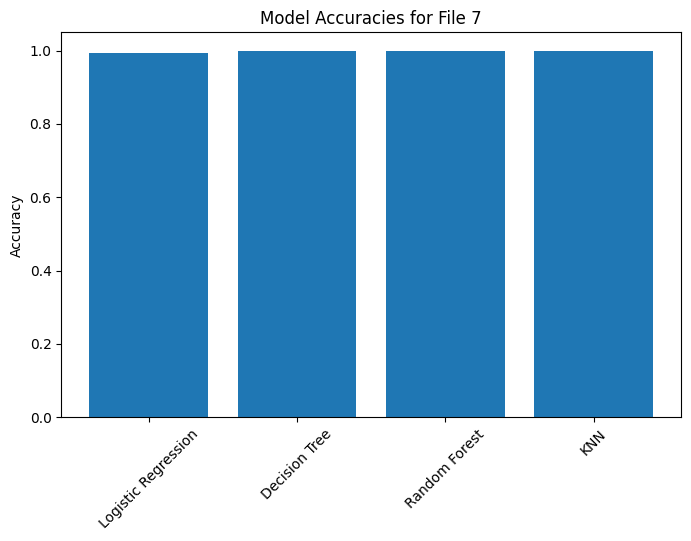

In [ ]:
#STEP 8 — Bar Chart of model accuracies (Run every time if you want the plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(accuracies7.keys(), accuracies7.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracies for File 7")
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

le7 = LabelEncoder()
le7.fit(df7[" Label"])   # Use your actual label column
print("Encoder rebuilt")

Encoder rebuilt


In [ ]:
#STEP 9 — Classification report (best model)(Run every time)
from sklearn.metrics import classification_report

best_model7 = models7["Random Forest"]
y7_pred = best_model7.predict(X7_test_scaled)

print(classification_report(y7_test, y7_pred, target_names=le7.classes_))


              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     86363
 FTP-Patator       1.00      1.00      1.00      1587
 SSH-Patator       1.00      1.00      1.00      1179

    accuracy                           1.00     89129
   macro avg       1.00      1.00      1.00     89129
weighted avg       1.00      1.00      1.00     89129



In [ ]:
# Step 10 — Find best model for File 7

best_model_name7 = max(accuracies7, key=accuracies7.get)
best_accuracy7 = accuracies7[best_model_name7]
best_model7 = models7[best_model_name7]

print("Best Model for File 7:", best_model_name7)
print("Accuracy:", best_accuracy7)


Best Model for File 7: Decision Tree
Accuracy: 1.0


In [ ]:
# Step 11 — Save best model for File 7 ran once

import joblib
import os

save_dir = "/content/drive/MyDrive/IDS_Project/Saved_Models"
os.makedirs(save_dir, exist_ok=True)

model_path7 = f"{save_dir}/IDS_File7_BestModel.pkl"
joblib.dump(best_model7, model_path7)

print("File 7 best model saved successfully!")
print("Saved at:", model_path7)


File 7 best model saved successfully!
Saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File7_BestModel.pkl


In [ ]:
# Step 6.3 — Load saved model for File 7

import joblib

model7 = joblib.load(
    "/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File7_BestModel.pkl"
)

print("File 7 model loaded successfully!")


File 7 model loaded successfully!


In [ ]:
# Step 6.4 — Make a prediction (File 7)

sample = X7_test_scaled[0:1]
prediction = model7.predict(sample)

print("Predicted label:", prediction[0])

if prediction[0] == 0:
    print("Prediction: BENIGN traffic")
else:
    print("Prediction: INTRUSION detected")


Predicted label: BENIGN
Prediction: INTRUSION detected


In [ ]:
#Step 13: Load the File 8 (Run every time)
import pandas as pd

file8 = "/content/drive/MyDrive/IDS_Project/Wednesday-workingHours.pcap_ISCX.csv"   # update path if needed
df8 = pd.read_csv(file8)

print("File 8 loaded successfully!")
df8.head()


File 8 loaded successfully!


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Step 8 — Clean File 8 (Run Once Only Unless File Changes)

import numpy as np

# Replace infinities with NaN
df8 = df8.replace([np.inf, -np.inf], np.nan)

# Drop NaN rows
df8 = df8.dropna()

print("After cleaning:", df8.shape)

# Save the cleaned dataset
save_path = "/content/drive/MyDrive/IDS_Project/Cleaned/Wednesday_WorkingHours_clean.csv"
df8.to_csv(save_path, index=False)

print(" Cleaned file saved to:", save_path)


After cleaning: (691406, 80)
 Cleaned file saved to: /content/drive/MyDrive/IDS_Project/Cleaned/Wednesday_WorkingHours_clean.csv


In [ ]:
print(df8.columns)


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [ ]:
# STEP 2 — Encode Labels (RUN ONCE)
from sklearn.preprocessing import LabelEncoder

label_col8 = " Label"

le8 = LabelEncoder()
df8["encoded_label"] = le8.fit_transform(df8[label_col8])

print("Classes:", le8.classes_)


Classes: ['BENIGN' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris'
 'Heartbleed']


In [ ]:
#STEP 3 — Prepare Features (RUN ONCE)
X8 = df8.drop(columns=[label_col8, "encoded_label"])
y8 = df8["encoded_label"]


In [ ]:
import numpy as np

# Replace inf with NaN
X8 = X8.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN
X8 = X8.dropna()

# IMPORTANT → keep labels aligned
y8 = y8.loc[X8.index]

print("After fixing infinities:", X8.shape)

After fixing infinities: (691406, 78)


In [ ]:
#STEP 4 — Train/Test Split + Scaling (RUN ONCE)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8, y8, test_size=0.2, random_state=42, stratify=y8
)

scaler8 = StandardScaler()
X8_train_scaled = scaler8.fit_transform(X8_train)
X8_test_scaled = scaler8.transform(X8_test)


In [ ]:
#STEP 5 — Train Models (RUN ONCE)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models8 = {
    "LogisticRegression": LogisticRegression(max_iter=200),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results8 = {}

for name, model in models8.items():
    print(f"Training {name}...")
    model.fit(X8_train_scaled, y8_train)
    pred = model.predict(X8_test_scaled)
    acc = accuracy_score(y8_test, pred)
    results8[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

results8


Training LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Accuracy: 0.9885
Training DecisionTree...
DecisionTree Accuracy: 0.9995
Training RandomForest...
RandomForest Accuracy: 0.9994
Training ExtraTrees...
ExtraTrees Accuracy: 0.9991
Training GradientBoosting...
GradientBoosting Accuracy: 0.9995
Training AdaBoost...
AdaBoost Accuracy: 0.9734
Training KNN...
KNN Accuracy: 0.9991
Training SVM...
SVM Accuracy: 0.9901


{'LogisticRegression': 0.9884872940802129,
 'DecisionTree': 0.9994648616595074,
 'RandomForest': 0.9993780824691573,
 'ExtraTrees': 0.9990743553029316,
 'GradientBoosting': 0.9994865564570949,
 'AdaBoost': 0.9734238729552653,
 'KNN': 0.9991249764973026,
 'SVM': 0.9900710143041032}

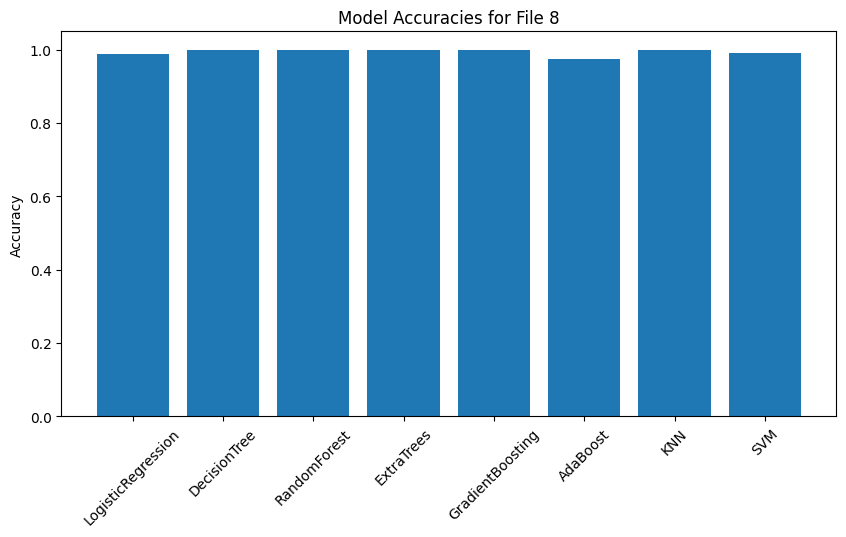

In [ ]:
#STEP 6 — Bar Chart of Accuracies (RUN ONCE)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results8.keys(), results8.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracies for File 8")
plt.show()


In [ ]:
#Step 7- select best model and save best model for file 8 (ran once)
import joblib
import os

best_model8_name = max(results8, key=results8.get)
best_model8 = models8[best_model8_name]
print(best_model8_name, results8[best_model8_name])

save_dir = "/content/drive/MyDrive/IDS_Project/Saved_Models"
os.makedirs(save_dir, exist_ok=True)

model_path = f"{save_dir}/IDS_File8_BestModel.pkl"
joblib.dump(best_model8, model_path)

print("✅ File 8 best model saved at:", model_path)


GradientBoosting 0.9994865564570949
✅ File 8 best model saved at: /content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File8_BestModel.pkl


In [ ]:
#STEP 8 — Load saved model (RUN EVERY TIME)
import joblib

model8 = joblib.load("/content/drive/MyDrive/IDS_Project/Saved_Models/IDS_File8_BestModel.pkl")
print("File 8 model loaded successfully!")


File 8 model loaded successfully!


In [ ]:
#Step 9- Prediction cell
sample = X8_test_scaled[0:1]
prediction = model8.predict(sample)

print("Predicted class:", prediction[0])
print("Decoded label:", le8.inverse_transform(prediction)[0])


Predicted class: 2
Decoded label: DoS Hulk


In [ ]:
#MERGING ALL 8 FILES

In [ ]:
# A — Load all cleaned files (Run Every Time)
import pandas as pd

clean_path = "/content/drive/MyDrive/IDS_Project/Cleaned/"

df1 = pd.read_csv(clean_path + "Friday_Afternoon_DDoS_clean.csv")
df2 = pd.read_csv(clean_path + "Friday_Afternoon_PortScan_clean.csv")
df3 = pd.read_csv(clean_path + "Friday_Morning_clean.csv")
df4 = pd.read_csv(clean_path + "Monday_WorkingHours_clean.csv")
df5 = pd.read_csv(clean_path + "Thursday_Afternoon_Infiltration_clean.csv")
df6 = pd.read_csv(clean_path + "Thursday_Morning_WebAttacks_clean.csv")
df7 = pd.read_csv(clean_path + "Tuesday_WorkingHours_clean.csv")
df8 = pd.read_csv(clean_path + "Wednesday_WorkingHours_clean.csv")

print("Loaded shapes:", [df.shape for df in (df1,df2,df3,df4,df5,df6,df7,df8)])


Loaded shapes: [(225711, 79), (286096, 79), (190911, 79), (529481, 79), (288584, 79), (170366, 79), (445645, 79), (691406, 80)]


In [ ]:
# B — unify label column name (Run Every Time)
def fix_label_column(df):
    for col in df.columns:
        if "label" in col.lower():
            df = df.rename(columns={col: "Label"})
            return df
    raise Exception("No label column found!")

df_list = []
for d in (df1,df2,df3,df4,df5,df6,df7,df8):
    df_list.append(fix_label_column(d))

# quick sanity
for i, d in enumerate(df_list, start=1):
    print(i, d['Label'].nunique(), "unique labels, total rows:", len(d))


1 2 unique labels, total rows: 225711
2 2 unique labels, total rows: 286096
3 2 unique labels, total rows: 190911
4 1 unique labels, total rows: 529481
5 2 unique labels, total rows: 288584
6 4 unique labels, total rows: 170366
7 3 unique labels, total rows: 445645
8 6 unique labels, total rows: 691406


In [ ]:
#B.1 merge all cleaned files
df = pd.concat(df_list, axis=0)

print("Final merged shape.", df.shape)
df.head()

Final merged shape. (2828200, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,encoded_label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN


In [ ]:
#B.2 save the merged dataset
save_path = "/content/drive/MyDrive/IDS_Project/merged_dataset.csv"
df.to_csv(save_path, index=False)

print("Merged dataset saved successfully")

Merged dataset saved successfully


In [ ]:
# C — show counts per file and overall (Run Every Time)
import collections
all_counts = {}
for i, d in enumerate(df_list, start=1):
    counts = d['Label'].value_counts()
    all_counts[f"file{i}"] = counts
    print(f"File{i} top labels:\n", counts.head(), "\n")

# Combined counts
combined_counts = pd.concat([d['Label'] for d in df_list], ignore_index=True).value_counts()
print("Combined label counts (all cleaned files):\n", combined_counts)


File1 top labels:
 Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64 

File2 top labels:
 Label
PortScan    158804
BENIGN      127292
Name: count, dtype: int64 

File3 top labels:
 Label
BENIGN    188955
Bot         1956
Name: count, dtype: int64 

File4 top labels:
 Label
BENIGN    529481
Name: count, dtype: int64 

File5 top labels:
 Label
BENIGN          288548
Infiltration        36
Name: count, dtype: int64 

File6 top labels:
 Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64 

File7 top labels:
 Label
BENIGN         431813
FTP-Patator      7935
SSH-Patator      5897
Name: count, dtype: int64 

File8 top labels:
 Label
BENIGN              439683
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64 

Combined label counts (all cleaned files):
 Label
BENIGN  

In [ ]:
# D- NEW SMART SAMPLING
import numpy as np
import pandas as pd

combined = pd.concat(df_list, ignore_index=True)
class_counts = combined["Label"].value_counts()

smart_samples = []
max_per_class = 2000   # you may increase to 3000 if Colab allows

for label, count in class_counts.items():
    subset = combined[combined["Label"] == label]

    # if class is tiny → keep all
    if count < 200:
        smart_samples.append(subset)
    else:
        smart_samples.append(subset.sample(n=min(count, max_per_class), random_state=42))

smart_combined = pd.concat(smart_samples, ignore_index=True)
print("New sampled shape:", smart_combined.shape)
print("Class distribution:\n", smart_combined["Label"].value_counts())


New sampled shape: (22183, 80)
Class distribution:
 Label
BENIGN                        2000
DoS Hulk                      2000
PortScan                      2000
DDoS                          2000
DoS GoldenEye                 2000
FTP-Patator                   2000
SSH-Patator                   2000
DoS slowloris                 2000
DoS Slowhttptest              2000
Bot                           1956
Web Attack � Brute Force      1507
Web Attack � XSS               652
Infiltration                    36
Web Attack � Sql Injection      21
Heartbleed                      11
Name: count, dtype: int64


In [ ]:
#NEW CELL E — Keep dataset as is
balanced = smart_combined.copy()
print("Final dataset shape:", balanced.shape)
print(balanced["Label"].value_counts())


Final dataset shape: (22183, 80)
Label
BENIGN                        2000
DoS Hulk                      2000
PortScan                      2000
DDoS                          2000
DoS GoldenEye                 2000
FTP-Patator                   2000
SSH-Patator                   2000
DoS slowloris                 2000
DoS Slowhttptest              2000
Bot                           1956
Web Attack � Brute Force      1507
Web Attack � XSS               652
Infiltration                    36
Web Attack � Sql Injection      21
Heartbleed                      11
Name: count, dtype: int64


In [ ]:
# Recreate df_final from the last balancing step
df_final = balanced.copy()

print("df_final restored. Shape:", df_final.shape)
print(df_final['Label'].value_counts())


df_final restored. Shape: (22183, 80)
Label
BENIGN                        2000
DoS Hulk                      2000
PortScan                      2000
DDoS                          2000
DoS GoldenEye                 2000
FTP-Patator                   2000
SSH-Patator                   2000
DoS slowloris                 2000
DoS Slowhttptest              2000
Bot                           1956
Web Attack � Brute Force      1507
Web Attack � XSS               652
Infiltration                    36
Web Attack � Sql Injection      21
Heartbleed                      11
Name: count, dtype: int64


In [ ]:
# Cell F — Label Encoding

from sklearn.preprocessing import LabelEncoder

# Make a copy so it's clean
df_final_encoded = df_final.copy()

# Initialize encoder
label_encoder = LabelEncoder()

# Encode
df_final_encoded["Label"] = label_encoder.fit_transform(df_final_encoded["Label"])

# Show mapping so you know which attack = which number
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:")
print(label_mapping)

# Split X and y
X = df_final_encoded.drop("Label", axis=1)
y = df_final_encoded["Label"]

print("\nShapes:")
print("X:", X.shape)
print("y:", y.shape)


Label Encoding Mapping:
{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}

Shapes:
X: (22183, 79)
y: (22183,)


In [ ]:
df_final_encoded['Label'].value_counts()

,count
Label,
0,2000
4,2000
10,2000
2,2000
3,2000
7,2000
11,2000
6,2000
5,2000


In [ ]:
# Cell G: Split + Scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")


Train shapes: (17746, 79) (17746,)
Test shapes: (4437, 79) (4437,)
Scaling complete.


In [ ]:
# Cell H — Train Classical ML Models (Random Forest + XGBoost)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, rf_preds))


# --- Train XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    tree_method='hist'
)
xgb.fit(X_train_scaled, y_train)

xgb_preds = xgb.predict(X_test_scaled)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, xgb_preds))


Random Forest Accuracy: 0.9650664863646609

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       400
           1       0.99      1.00      1.00       391
           2       1.00      1.00      1.00       400
           3       1.00      0.99      0.99       400
           4       1.00      1.00      1.00       400
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       400
           7       1.00      1.00      1.00       400
           8       1.00      1.00      1.00         2
           9       1.00      0.71      0.83         7
          10       1.00      1.00      1.00       400
          11       1.00      1.00      1.00       400
          12       0.74      0.81      0.78       302
          13       1.00      0.25      0.40         4
          14       0.45      0.34      0.39       131

    accuracy                           0.97      443

In [ ]:
# Restore predictions for Confusion Matrix

# Random Forest predictions
rf_pred = rf.predict(X_test_scaled)

# XGBoost predictions
xgb_pred = xgb.predict(X_test_scaled)

print("Predictions restored!")


Predictions restored!


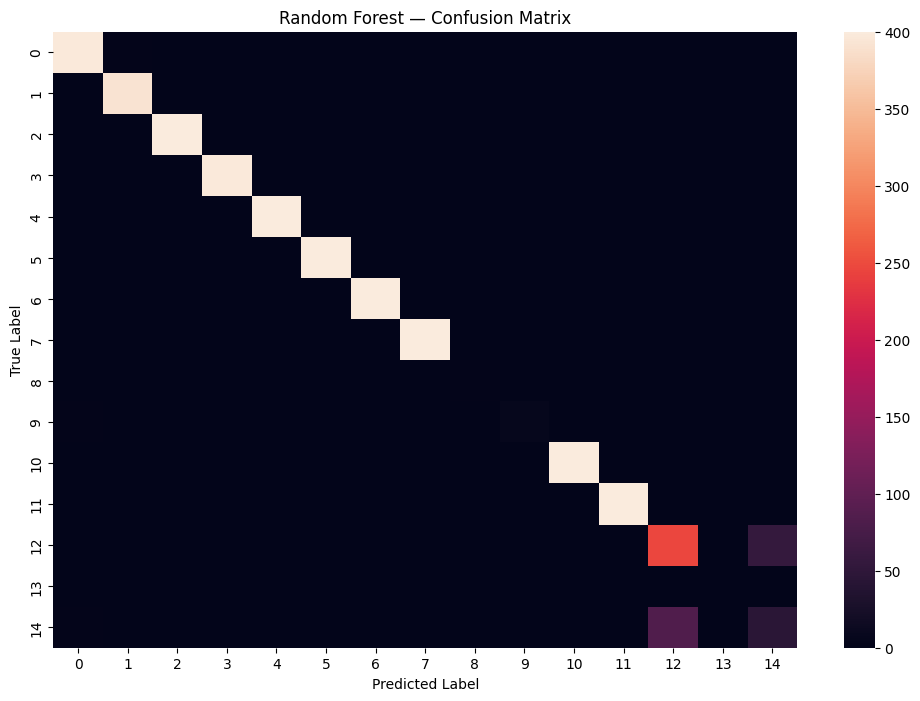

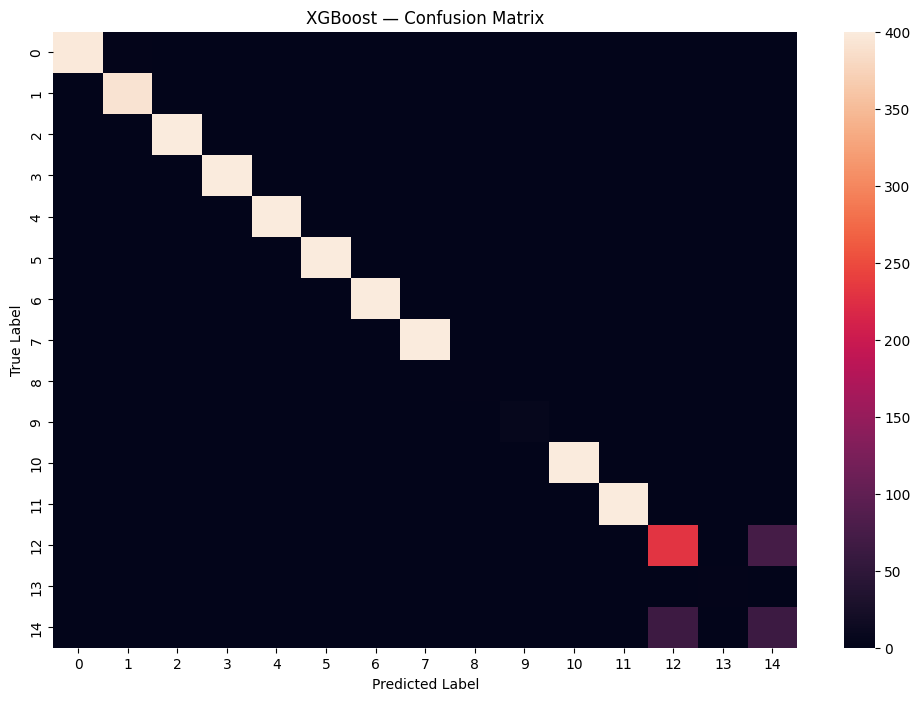

In [ ]:
# Cell I — Confusion Matrices for Random Forest & XGBoost

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns  # don't worry, seaborn is allowed for confusion matrix heatmaps :)

# --- Random Forest Confusion Matrix ---
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(rf_cm, annot=False, fmt="d")
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- XGBoost Confusion Matrix ---
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(xgb_cm, annot=False, fmt="d")
plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
# Recreate df_final (this is Cell E logic)

df_final = balanced.copy()

print("df_final recreated")
print("Shape:", df_final.shape)
print(df_final["Label"].value_counts())


df_final recreated
Shape: (22183, 80)
Label
BENIGN                        2000
DoS Hulk                      2000
PortScan                      2000
DDoS                          2000
DoS GoldenEye                 2000
FTP-Patator                   2000
SSH-Patator                   2000
DoS slowloris                 2000
DoS Slowhttptest              2000
Bot                           1956
Web Attack � Brute Force      1507
Web Attack � XSS               652
Infiltration                    36
Web Attack � Sql Injection      21
Heartbleed                      11
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_final_encoded = df_final.copy()

le = LabelEncoder()
df_final_encoded["Label"] = le.fit_transform(df_final_encoded["Label"])

print("Encoded OK")
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))


Encoded OK
Classes: {'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}


In [ ]:
# Cell J — Prepare data for LSTM

import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and labels
X = df_final_encoded.drop("Label", axis=1).values
y = df_final_encoded["Label"].values

# One-hot encode labels for LSTM
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("LSTM input shape:", X_train_lstm.shape)
print("LSTM output shape:", y_train.shape)
print("Number of classes:", num_classes)


LSTM input shape: (17746, 1, 79)
LSTM output shape: (17746, 15)
Number of classes: 15


In [ ]:
#Cell K — Build & Train LSTM (Run Once)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set seed for reproducibility
tf.random.set_seed(42)

# Build the model (same architecture, but with Input layer)
model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(y_train.shape[1], activation="softmax")
])

# Compile with gradient clipping (clipnorm=1.0)
optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

# Train
history = model.fit(
    X_train_lstm, y_train,
    epochs=50,                # increased; early stopping will cut off
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# After training, evaluate quickly
y_pred_probs = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print("Test accuracy:", np.mean(y_pred == y_true))

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0896 - loss: nan - val_accuracy: 0.0868 - val_loss: nan - learning_rate: 0.0010
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0903 - loss: nan - val_accuracy: 0.0868 - val_loss: nan - learning_rate: 0.0010
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0903 - loss: nan - val_accuracy: 0.0868 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0903 - loss: nan - val_accuracy: 0.0868 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0903 - loss: nan - val_accuracy: 0.0868 - val_loss: nan - learning_rate: 2.5000e-04
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0903 - loss: nan - val_accuracy: 0.0868 - val_loss: nan - learning_rate: 2.5000e-04
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test accuracy: 0.09015100292990759


In [ ]:
import joblib
import pickle

# Save the Keras model
model.save('lstm_fixed_model.keras')   # or .h5

# Save the scaler (already exists, but save again to be safe)
joblib.dump(scaler, 'lstm_scaler.pkl')

# Save the label encoder
with open('lstm_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# --- Get feature columns from the DataFrame (before conversion to NumPy) ---
# df_final_encoded still exists and has the features + 'Label'
feature_columns = df_final_encoded.drop('Label', axis=1).columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("✅ All files saved. Download them now.")

✅ All files saved. Download them now.


In [ ]:
#Check model's perfoemance
# Predict on the test set
y_pred_probs = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Show unique predictions
print("Unique predicted classes:", np.unique(y_pred))
print("True class distribution:", np.unique(y_true, return_counts=True))

# Compute accuracy
from sklearn.metrics import accuracy_score, classification_report
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Unique predicted classes: [0]
True class distribution: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([400, 391, 400, 400, 400, 400, 400, 400,   2,   7, 400, 400, 302,
         4, 131]))
Test Accuracy: 0.0902

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       0.09      1.00      0.17       400
                       Bot       0.00      0.00      0.00       391
                      DDoS       0.00      0.00      0.00       400
             DoS GoldenEye       0.00      0.00      0.00       400
                  DoS Hulk       0.00      0.00      0.00       400
          DoS Slowhttptest       0.00      0.00      0.00       400
             DoS slowloris       0.00      0.00      0.00       400
               FTP-Patator       0.00      0.00      0.00       400
                Heartbleed       0.00      0.00      0.00         2
              In

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Cell L — LSTM Evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Predict on test data
y_pred_probs = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
test_acc = accuracy_score(y_true, y_pred)
print("LSTM Test Accuracy:", test_acc)

# Classification report
print("\nClassification Report (LSTM):\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Test Accuracy: 0.09015100292990759

Classification Report (LSTM):

                            precision    recall  f1-score   support

                    BENIGN       0.09      1.00      0.17       400
                       Bot       0.00      0.00      0.00       391
                      DDoS       0.00      0.00      0.00       400
             DoS GoldenEye       0.00      0.00      0.00       400
                  DoS Hulk       0.00      0.00      0.00       400
          DoS Slowhttptest       0.00      0.00      0.00       400
             DoS slowloris       0.00      0.00      0.00       400
               FTP-Patator       0.00      0.00      0.00       400
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.00      0.00      0.00       400
               SSH-Patator       0.00      0.00      0.00       400
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


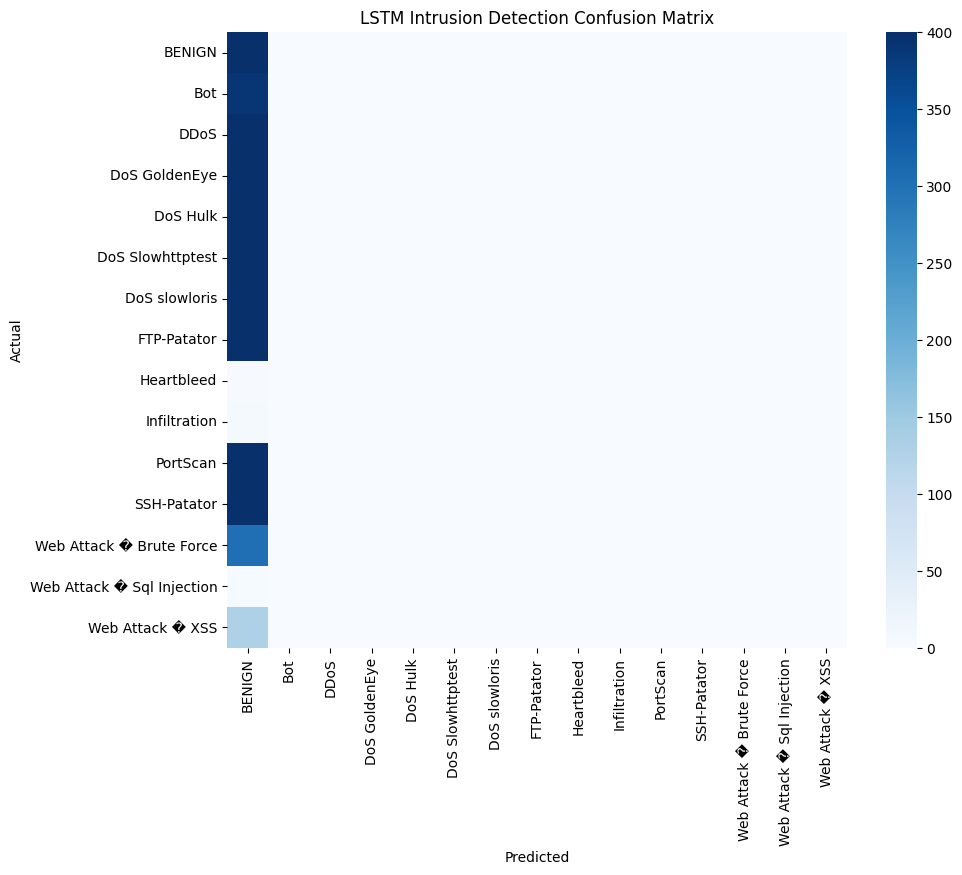

In [ ]:
# Save LSTM confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Intrusion Detection Confusion Matrix")
plt.savefig("/content/drive/MyDrive/IDS_Project/LSTM_Confusion_Matrix.png")
plt.show()


In [ ]:
#Choose Rrandom forest model as the final model
import joblib
import pickle

# 1. Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')

# 2. Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# 3. Save the label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# 4. Save the feature column names (from df_final_encoded, dropping 'Label')
feature_columns = df_final_encoded.drop('Label', axis=1).columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("✅ All files saved:")
print(" - rf_model.pkl")
print(" - scaler.pkl")
print(" - label_encoder.pkl")
print(" - feature_columns.pkl")
print(f"Number of features: {len(feature_columns)}")

# Download them
from google.colab import files
files.download('rf_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')
files.download('feature_columns.pkl')

✅ All files saved:
 - rf_model.pkl
 - scaler.pkl
 - label_encoder.pkl
 - feature_columns.pkl
Number of features: 79


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# Assuming df_final_encoded has columns: features + 'Label' (encoded target)
# We'll take a mix of samples from different attack types

# Separate features and target
X = df_final_encoded.drop('Label', axis=1)
y = df_final_encoded['Label']

# Get indices of a few samples from each class (e.g., first 2 from each)
indices = []
for class_label in range(15):  # you have 15 classes
    class_indices = y[y == class_label].index[:2]  # first 2 samples of this class
    indices.extend(class_indices)

# Subset the features using these indices
test_mixed = X.loc[indices]

# Shuffle to mix classes (optional)
test_mixed = test_mixed.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
test_mixed.to_csv('mixed_test.csv', index=False)

# Download the file
files.download('mixed_test.csv')

print("✅ mixed_test.csv created and downloaded.")
print("Shape:", test_mixed.shape)
print("Number of samples:", len(test_mixed))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ mixed_test.csv created and downloaded.
Shape: (30, 79)
Number of samples: 30


In [ ]:
import pandas as pd
from google.colab import files

# Assume df_final_encoded has features + 'Label' (encoded)
X = df_final_encoded.drop('Label', axis=1)
y = df_final_encoded['Label']

# Get indices for 2 samples from each class (0 = BENIGN, 1..14 = attacks)
indices = []
true_labels = []
for class_id in range(15):          # all 15 classes
    class_indices = y[y == class_id].index[:2]   # first 2 samples
    indices.extend(class_indices)
    true_labels.extend([class_id] * len(class_indices))

# Create test DataFrame (features only)
test_mixed = X.loc[indices].reset_index(drop=True)

# Show true label counts
print("True label distribution in test set:")
print(pd.Series(true_labels).value_counts().sort_index())

# Save test file (without labels)
test_mixed.to_csv('mixed_test.csv', index=False)
files.download('mixed_test.csv')

True label distribution in test set:
0     2
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2
13    2
14    2
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>